# How Reliably Can an NLP Model Trained on Social Media Emotions Identify Fine-Grained Emotions in Customer Support Messages?

**MSIN0221: Natural Language Processing — Team 1**

**Members:** Leya Sherman, Marcus Hudson, Majid Ahmadi Moghaddam, Pablo Williams, Salman Khalid

---

### Member Contributions
| Member | Contribution |
|--------|-------------|
| Leya Sherman | Data preprocessing, BERT fine-tuning, model training |
| Salman Khalid | Baseline model, evaluation framework, results analysis |
| Marcus Hudson | Introduction, literature review, error analysis, discussion |
| Majid Ahmadi Moghaddam | Methodology write-up |
| Pablo Williams | Presentation slides |

---

In [30]:
#!pip install -q kaggle


In [31]:
#from google.colab import files
#files.upload()


In [32]:
#!mkdir -p ~/.kaggle
#!mv kaggle.json ~/.kaggle/
#!chmod 600 ~/.kaggle/kaggle.json


In [33]:
#!kaggle datasets download -d thoughtvector/customer-support-on-twitter
#!unzip -q customer-support-on-twitter.zip


In [34]:
#!ls -lh /content/twcs.csv


In [35]:
#!find /content -name "*.csv" -maxdepth 2



## 1. Setup and Installation

In [36]:
# Install required libraries (uncomment if needed)
# !pip install transformers datasets torch scikit-learn pandas matplotlib seaborn

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP and ML
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
import torch

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## 2. Data Acquisition and Exploration
### 2.1 Load GoEmotions Dataset

In [38]:
# Load GoEmotions from HuggingFace
goemotions = load_dataset('go_emotions', 'simplified')

print("Dataset splits:")
print(goemotions)
print(f"\nTraining examples: {len(goemotions['train'])}")
print(f"Validation examples: {len(goemotions['validation'])}")
print(f"Test examples: {len(goemotions['test'])}")

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Training examples: 43410
Validation examples: 5426
Test examples: 5427


In [39]:
# GoEmotions emotion labels (27 emotions + neutral)
emotion_labels = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse',
    'sadness', 'surprise', 'neutral'
]

print(f"Number of emotion categories: {len(emotion_labels)}")
print(f"\nEmotion labels: {emotion_labels}")

Number of emotion categories: 28

Emotion labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [40]:
# Inspect a few examples
print("Sample entries from GoEmotions:")
for i in range(5):
    example = goemotions['train'][i]
    labels = [emotion_labels[l] for l in example['labels']]
    print(f"\nText: {example['text']}")
    print(f"Labels: {labels}")

Sample entries from GoEmotions:

Text: My favourite food is anything I didn't have to cook myself.
Labels: ['neutral']

Text: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Labels: ['neutral']

Text: WHY THE FUCK IS BAYLESS ISOING
Labels: ['anger']

Text: To make her feel threatened
Labels: ['fear']

Text: Dirty Southern Wankers
Labels: ['annoyance']


In [41]:
# NOTE: GoEmotions supports multi-label classification (one text can have multiple emotions).
# For simplicity, we'll convert to single-label by taking the FIRST label for each example.
# This is a common approach and should be noted as a methodological choice in the report.

def to_single_label(example):
    """Convert multi-label to single-label by taking the first label."""
    example['label'] = example['labels'][0]
    return example

goemotions_single = goemotions.map(to_single_label)

print("Converted to single-label classification.")
print(f"Sample - Text: {goemotions_single['train'][0]['text']}")
print(f"Sample - Label: {emotion_labels[goemotions_single['train'][0]['label']]}")

Converted to single-label classification.
Sample - Text: My favourite food is anything I didn't have to cook myself.
Sample - Label: neutral


### 2.2 Exploratory Data Analysis — GoEmotions

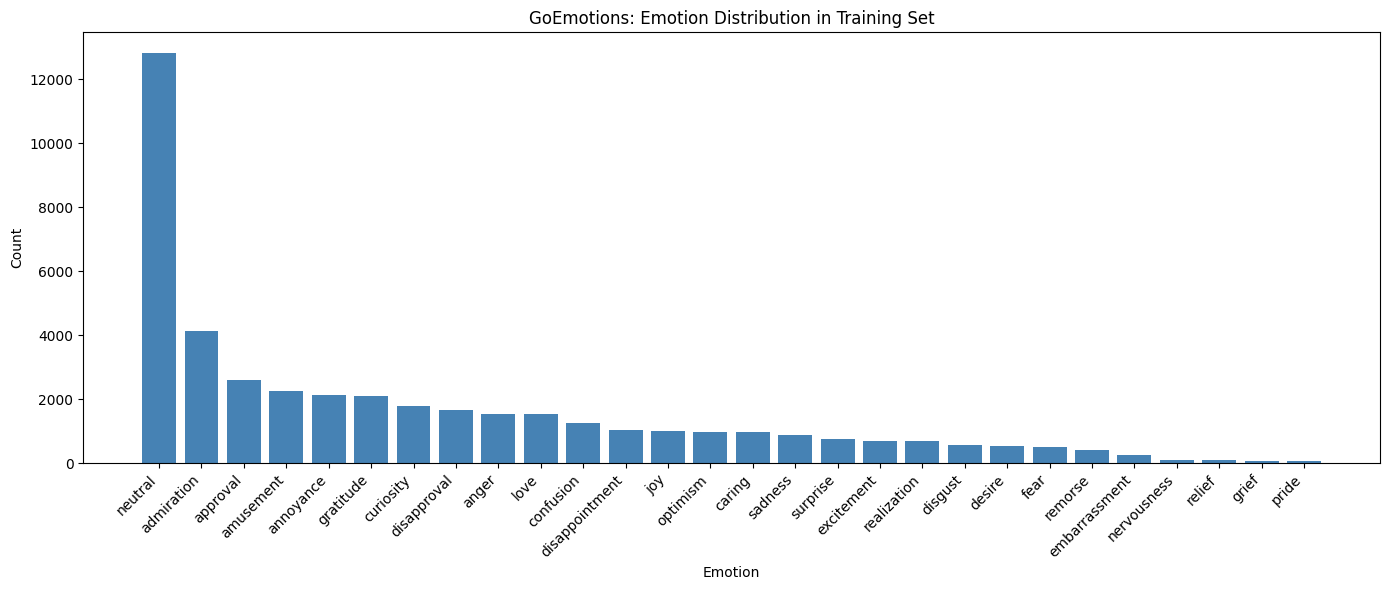


Class distribution:
  neutral             : 12823 (29.5%)
  admiration          :  4130 (9.5%)
  approval            :  2596 (6.0%)
  amusement           :  2244 (5.2%)
  annoyance           :  2138 (4.9%)
  gratitude           :  2096 (4.8%)
  curiosity           :  1772 (4.1%)
  disapproval         :  1651 (3.8%)
  anger               :  1547 (3.6%)
  love                :  1533 (3.5%)
  confusion           :  1268 (2.9%)
  disappointment      :  1028 (2.4%)
  joy                 :  1013 (2.3%)
  optimism            :   974 (2.2%)
  caring              :   966 (2.2%)
  sadness             :   874 (2.0%)
  surprise            :   751 (1.7%)
  excitement          :   700 (1.6%)
  realization         :   698 (1.6%)
  disgust             :   580 (1.3%)
  desire              :   543 (1.3%)
  fear                :   510 (1.2%)
  remorse             :   404 (0.9%)
  embarrassment       :   248 (0.6%)
  nervousness         :   105 (0.2%)
  relief              :    96 (0.2%)
  grief         

In [42]:
# Emotion distribution in training set
train_labels = [emotion_labels[ex['label']] for ex in goemotions_single['train']]
label_counts = Counter(train_labels)

# Sort by frequency
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels_sorted, counts_sorted = zip(*sorted_labels)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(labels_sorted, counts_sorted, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('GoEmotions: Emotion Distribution in Training Set')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('goemotions_distribution.png', dpi=150)
plt.show()

print("\nClass distribution:")
for label, count in sorted_labels:
    print(f"  {label:20s}: {count:5d} ({count/len(train_labels)*100:.1f}%)")

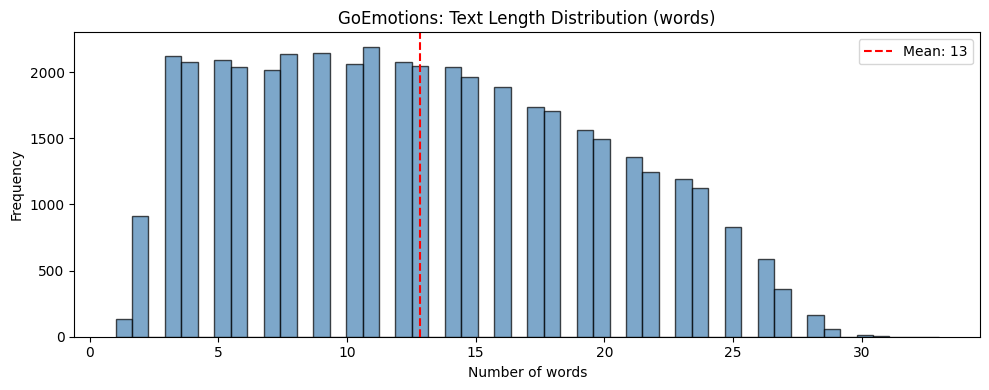

In [43]:
# Text length distribution
train_lengths = [len(ex['text'].split()) for ex in goemotions_single['train']]

plt.figure(figsize=(10, 4))
plt.hist(train_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('GoEmotions: Text Length Distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.axvline(np.mean(train_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(train_lengths):.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('goemotions_text_lengths.png', dpi=150)
plt.show()

### 2.3 Load and Prepare Twitter Customer Support Dataset

**Instructions:** Download the dataset from [Kaggle](https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter/data) and place the CSV file in your project directory.

In [44]:
import os
for d, s, f in os.walk('/kaggle/input'):
    for name in f:
        print(os.path.join(d, name))


/kaggle/input/datasets/saluds11/labelled-file/tweets_for_annotation.xlsx
/kaggle/input/datasets/organizations/thoughtvector/customer-support-on-twitter/sample.csv
/kaggle/input/datasets/organizations/thoughtvector/customer-support-on-twitter/twcs/twcs.csv


In [45]:
# Load Twitter Customer Support dataset
# UPDATE THIS PATH to where you saved the CSV
#twitter_df = pd.read_csv('/content/twcs/twcs.csv') ..for colab
twitter_df = pd.read_csv('/kaggle/input/datasets/organizations/thoughtvector/customer-support-on-twitter/twcs/twcs.csv')



print(f"Total rows: {len(twitter_df)}")
print(f"\nColumns: {twitter_df.columns.tolist()}")
print(f"\nFirst few rows:")
twitter_df.head()

Total rows: 2811774

Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

First few rows:


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [46]:
# Filter to CUSTOMER messages only (not brand responses)
# In this dataset, 'inbound' == True means the customer is writing TO the brand
customer_tweets = twitter_df[twitter_df['inbound'] == True].copy()
print(f"Customer messages: {len(customer_tweets)}")

# Drop rows with missing text
customer_tweets = customer_tweets.dropna(subset=['text'])
print(f"After dropping NaN: {len(customer_tweets)}")

# Random sample of 10,000 for computational feasibility
np.random.seed(42)
twitter_sample = customer_tweets.sample(n=10000, random_state=42)
print(f"Sampled tweets: {len(twitter_sample)}")

# Preview
for i, row in twitter_sample.head(5).iterrows():
    print(f"\n{row['text'][:150]}...")

Customer messages: 1537843
After dropping NaN: 1537843
Sampled tweets: 10000

@AppleSupport Basically for a chat to be opened from call log, the message app should be opened/running in background. Otherwise, it takes twice....

@AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, notif. off/on does not help. What to do? https://t...

Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI...

@ATVIAssist Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the open beta multiplayer?...

Hi @Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable...


In [47]:
# Basic preprocessing for Twitter data
import re

def preprocess_tweet(text):
    """Light preprocessing - preserve emotional cues like punctuation and caps."""
    # Remove @mentions (replace with generic token)
    text = re.sub(r'@\w+', '@user', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

twitter_sample['text_clean'] = twitter_sample['text'].apply(preprocess_tweet)

# Preview cleaned tweets
for i, row in twitter_sample.head(5).iterrows():
    print(f"Original:  {row['text'][:100]}")
    print(f"Cleaned:   {row['text_clean'][:100]}")
    print()

Original:  @AppleSupport Basically for a chat to be opened from call log, the message app should be opened/runn
Cleaned:   @user Basically for a chat to be opened from call log, the message app should be opened/running in b

Original:  @AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, 
Cleaned:   @user iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, notif. o

Original:  Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI
Cleaned:   Dear god not again,@user

Original:  @ATVIAssist Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the ope
Cleaned:   @user Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the open beta

Original:  Hi @Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable
Cleaned:   Hi @user why can't I pay my my Dstv texts says the Org is unavailable



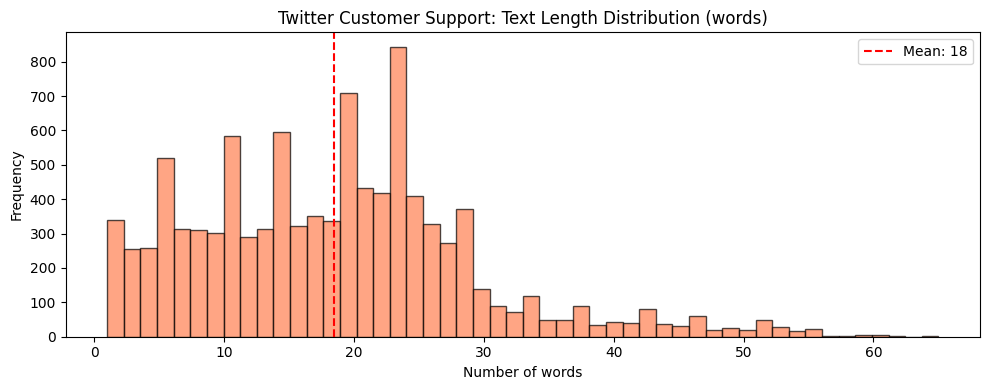

In [48]:
# Twitter text length distribution
twitter_lengths = twitter_sample['text_clean'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(twitter_lengths, bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Twitter Customer Support: Text Length Distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.axvline(twitter_lengths.mean(), color='red', linestyle='--', label=f'Mean: {twitter_lengths.mean():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('twitter_text_lengths.png', dpi=150)
plt.show()

---
## 3. Model Training
### 3.1 Baseline: Logistic Regression with TF-IDF

**Owner: Salman**

In [49]:
# Prepare data for baseline model
train_texts = [ex['text'] for ex in goemotions_single['train']]
train_labels_int = [ex['label'] for ex in goemotions_single['train']]

val_texts = [ex['text'] for ex in goemotions_single['validation']]
val_labels_int = [ex['label'] for ex in goemotions_single['validation']]

test_texts = [ex['text'] for ex in goemotions_single['test']]
test_labels_int = [ex['label'] for ex in goemotions_single['test']]

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 43410, Val: 5426, Test: 5427


In [50]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(train_texts)
X_val_tfidf = tfidf.transform(val_texts)
X_test_tfidf = tfidf.transform(test_texts)

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Feature matrix shape: {X_train_tfidf.shape}")

TF-IDF vocabulary size: 20000
Feature matrix shape: (43410, 20000)


In [51]:
# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)

print("Training Logistic Regression baseline...")
lr_model.fit(X_train_tfidf, train_labels_int)
print("Done!")

# Evaluate on GoEmotions test set
lr_preds = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(test_labels_int, lr_preds)
lr_f1_macro = f1_score(test_labels_int, lr_preds, average='macro')
lr_f1_weighted = f1_score(test_labels_int, lr_preds, average='weighted')

print(f"\n--- Logistic Regression on GoEmotions Test Set ---")
print(f"Accuracy:         {lr_accuracy:.4f}")
print(f"Macro F1:         {lr_f1_macro:.4f}")
print(f"Weighted F1:      {lr_f1_weighted:.4f}")

Training Logistic Regression baseline...
Done!

--- Logistic Regression on GoEmotions Test Set ---
Accuracy:         0.5032
Macro F1:         0.3050
Weighted F1:      0.4462


In [52]:
# Detailed classification report for baseline
print("\nClassification Report (Logistic Regression - GoEmotions Test):")
print(classification_report(
    test_labels_int, lr_preds,
    target_names=emotion_labels,
    zero_division=0
))


Classification Report (Logistic Regression - GoEmotions Test):
                precision    recall  f1-score   support

    admiration       0.62      0.60      0.61       504
     amusement       0.76      0.68      0.72       252
         anger       0.53      0.23      0.33       197
     annoyance       0.33      0.07      0.12       286
      approval       0.44      0.14      0.22       318
        caring       0.48      0.18      0.26       114
     confusion       0.44      0.15      0.22       139
     curiosity       0.44      0.19      0.26       233
        desire       0.58      0.20      0.30        74
disappointment       0.50      0.05      0.09       127
   disapproval       0.37      0.12      0.18       220
       disgust       0.63      0.26      0.37        84
 embarrassment       0.00      0.00      0.00        30
    excitement       0.60      0.21      0.32        84
          fear       0.72      0.18      0.28        74
     gratitude       0.82      0.83    

### 3.2 BERT Fine-Tuning on GoEmotions

**Owner: Leya**

In [53]:
# Tokenize data for BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# Tokenize all splits
tokenized_train = goemotions_single['train'].map(tokenize_function, batched=True)
tokenized_val = goemotions_single['validation'].map(tokenize_function, batched=True)
tokenized_test = goemotions_single['test'].map(tokenize_function, batched=True)

# Set format for PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_val.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization complete.")
print(f"Sample tokenized input shape: {tokenized_train[0]['input_ids'].shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Tokenization complete.
Sample tokenized input shape: torch.Size([128])


In [66]:
# Load BERT model with classification head
num_labels = len(emotion_labels)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels
)
model.to(device)

print(f"Model loaded with {num_labels} output labels.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded with 28 output labels.
Total parameters: 109,503,772


In [68]:
# Define compute_metrics for Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

In [69]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./bert_goemotions',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    report_to='none',  # Disable wandb etc.
    seed=42
)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("Trainer configured. Starting training...")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer configured. Starting training...


In [57]:
# Train the model (this will take a while - ~30-60 min with GPU)
train_result = trainer.train()

print("\n--- Training Complete ---")
print(f"Training loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,3.541855,3.194552,0.548470,0.344178,0.510801
2,2.827491,2.822160,0.585698,0.430867,0.565583
3,2.439888,2.784338,0.588832,0.441115,0.570528


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- Training Complete ---
Training loss: 3.3804


In [58]:
# Evaluate on GoEmotions test set
bert_eval = trainer.evaluate(tokenized_test)

print("\n--- BERT on GoEmotions Test Set ---")
print(f"Accuracy:         {bert_eval['eval_accuracy']:.4f}")
print(f"Macro F1:         {bert_eval['eval_f1_macro']:.4f}")
print(f"Weighted F1:      {bert_eval['eval_f1_weighted']:.4f}")


--- BERT on GoEmotions Test Set ---
Accuracy:         0.5839
Macro F1:         0.4300
Weighted F1:      0.5662


In [59]:
# Get predictions for detailed analysis
bert_predictions = trainer.predict(tokenized_test)
bert_preds = np.argmax(bert_predictions.predictions, axis=-1)
bert_true = bert_predictions.label_ids

print("\nClassification Report (BERT - GoEmotions Test):")
print(classification_report(
    bert_true, bert_preds,
    target_names=emotion_labels,
    zero_division=0
))


Classification Report (BERT - GoEmotions Test):
                precision    recall  f1-score   support

    admiration       0.66      0.78      0.72       504
     amusement       0.75      0.88      0.81       252
         anger       0.47      0.51      0.49       197
     annoyance       0.31      0.23      0.27       286
      approval       0.54      0.37      0.44       318
        caring       0.40      0.41      0.41       114
     confusion       0.45      0.40      0.42       139
     curiosity       0.44      0.57      0.50       233
        desire       0.60      0.36      0.45        74
disappointment       0.41      0.20      0.27       127
   disapproval       0.43      0.39      0.41       220
       disgust       0.49      0.40      0.44        84
 embarrassment       0.80      0.27      0.40        30
    excitement       0.53      0.36      0.43        84
          fear       0.60      0.70      0.65        74
     gratitude       0.85      0.84      0.84       28

In [60]:
# Save the fine-tuned model
trainer.save_model('./bert_goemotions_final')
tokenizer.save_pretrained('./bert_goemotions_final')
print("Model saved to ./bert_goemotions_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert_goemotions_final


---
## 4. In-Domain Evaluation (GoEmotions)

**Owner: Salman**

In [61]:
# Compare BERT vs Logistic Regression on GoEmotions
comparison = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'BERT (fine-tuned)'],
    'Accuracy': [lr_accuracy, bert_eval['eval_accuracy']],
    'Macro F1': [lr_f1_macro, bert_eval['eval_f1_macro']],
    'Weighted F1': [lr_f1_weighted, bert_eval['eval_f1_weighted']]
})

print("\n=== Model Comparison on GoEmotions Test Set ===")
print(comparison.to_string(index=False))


=== Model Comparison on GoEmotions Test Set ===
                       Model  Accuracy  Macro F1  Weighted F1
Logistic Regression (TF-IDF)  0.503225  0.305047     0.446242
           BERT (fine-tuned)  0.583932  0.429969     0.566174


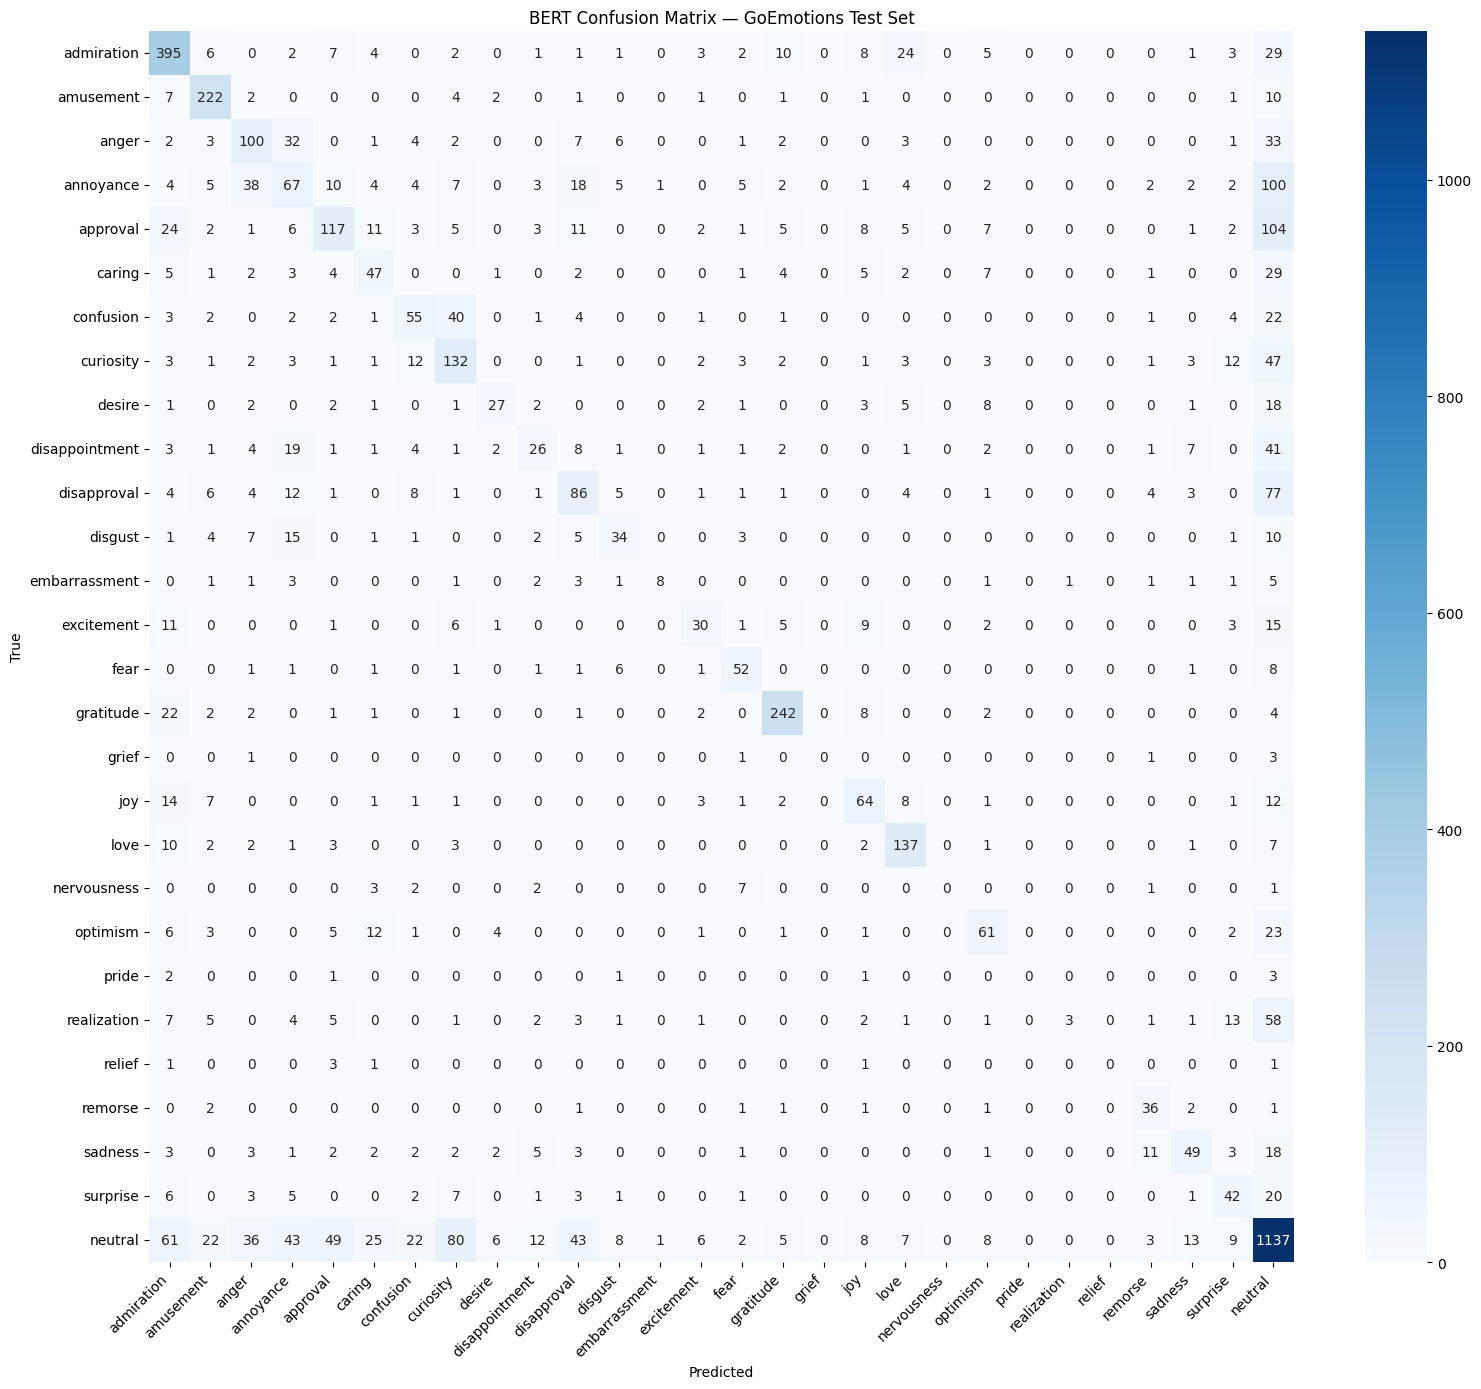

In [62]:
# Confusion Matrix for BERT on GoEmotions
cm = confusion_matrix(bert_true, bert_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_labels,
    yticklabels=emotion_labels
)
plt.title('BERT Confusion Matrix — GoEmotions Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_goemotions.png', dpi=150)
plt.show()

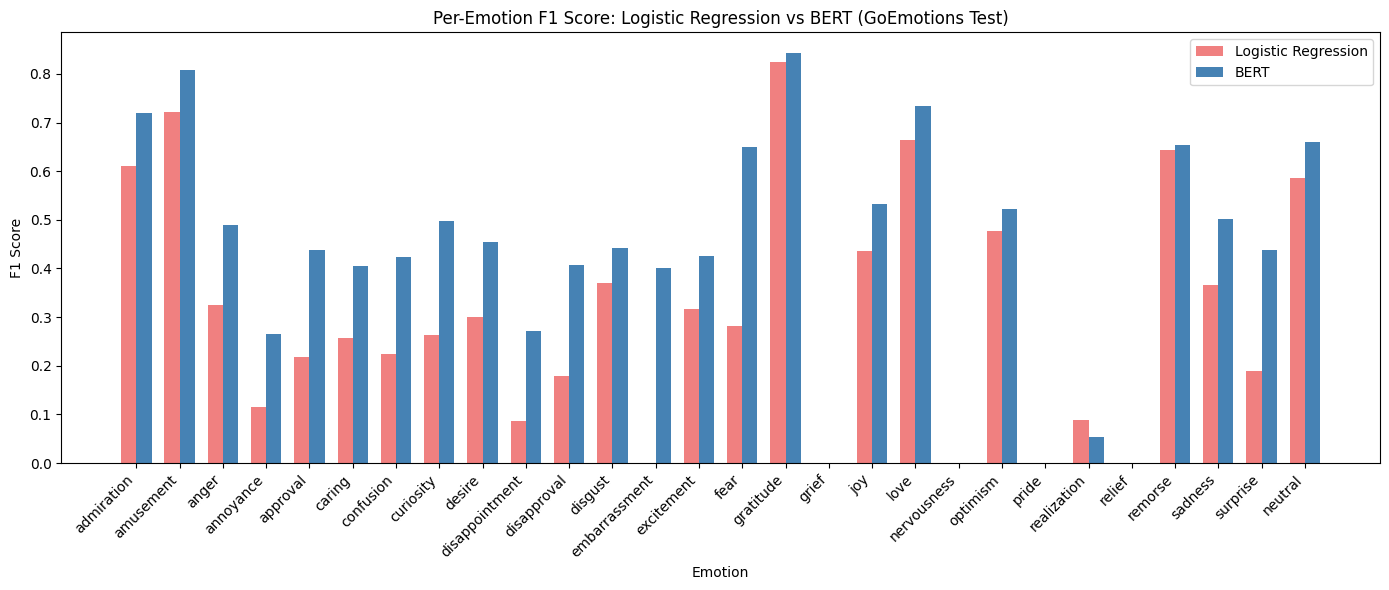

In [63]:
# Per-emotion F1 comparison between models
from sklearn.metrics import f1_score as f1_per_class

bert_f1_per_class = f1_score(bert_true, bert_preds, average=None, zero_division=0)
lr_f1_per_class = f1_score(test_labels_int, lr_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(emotion_labels))
width = 0.35

ax.bar(x - width/2, lr_f1_per_class, width, label='Logistic Regression', color='lightcoral')
ax.bar(x + width/2, bert_f1_per_class, width, label='BERT', color='steelblue')

ax.set_xlabel('Emotion')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Emotion F1 Score: Logistic Regression vs BERT (GoEmotions Test)')
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('per_emotion_f1_comparison.png', dpi=150)
plt.show()

---
## 5. Manual Annotation of Twitter Data

**Owners: Salman & Leya (250 each)**

This section documents the annotation process for the 500-tweet evaluation sample.

In [64]:
# Sample 500 tweets for manual annotation
annotation_sample = twitter_sample.sample(n=500, random_state=123)

# Export to CSV for annotation (annotators fill in the 'emotion_label' column)
annotation_df = annotation_sample[['tweet_id', 'text_clean']].copy()
annotation_df['annotator_1_label'] = ''  # Salman fills this
annotation_df['annotator_2_label'] = ''  # Leya fills this
annotation_df['final_label'] = ''        # Agreed label after discussion

annotation_df.to_csv('tweets_for_annotation.csv', index=False)
print(f"Exported {len(annotation_df)} tweets to 'tweets_for_annotation.csv'")
print("\nAnnotation guidelines:")
print("- Read each tweet and assign ONE primary emotion from the 28 GoEmotions labels")
print("- If multiple emotions are present, choose the DOMINANT one")
print("- If genuinely no emotion is detected, label as 'neutral'")
print(f"\nValid labels: {emotion_labels}")

Exported 500 tweets to 'tweets_for_annotation.csv'

Annotation guidelines:
- Read each tweet and assign ONE primary emotion from the 28 GoEmotions labels
- If multiple emotions are present, choose the DOMINANT one
- If genuinely no emotion is detected, label as 'neutral'

Valid labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [75]:
# ============================================================
# AFTER ANNOTATION IS COMPLETE: Load the annotated data
# ============================================================

# Uncomment and run after both annotators have filled in the CSV
annotated_df = pd.read_excel('/kaggle/input/datasets/saluds11/labelled-file/tweets_for_annotation.xlsx')



# # Calculate Inter-Annotator Agreement (Cohen's Kappa)
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(
     annotated_df['annotator_1_label'],
     annotated_df['annotator_2_label']
)
agreement_pct = (annotated_df['annotator_1_label'] == annotated_df['annotator_2_label']).mean()

print(f"Inter-Annotator Agreement:")
print(f"  Raw agreement: {agreement_pct:.2%}")
print(f"  Cohen's Kappa: {kappa:.4f}")
print(f"\nKappa interpretation: <0.2 poor, 0.2-0.4 fair, 0.4-0.6 moderate, 0.6-0.8 substantial, >0.8 excellent")

Inter-Annotator Agreement:
  Raw agreement: 77.40%
  Cohen's Kappa: 0.7333

Kappa interpretation: <0.2 poor, 0.2-0.4 fair, 0.4-0.6 moderate, 0.6-0.8 substantial, >0.8 excellent


---
## 6. Cross-Domain Evaluation (Twitter Customer Support)

**Owner: Salman**

In [84]:
# ============================================================
# Run AFTER annotation is complete and final_label column is filled
# ============================================================

# Run AFTER annotation is complete and final_label column is filled

# Load annotated tweets
annotated_df = pd.read_excel('/kaggle/input/datasets/saluds11/labelled-file/tweets_for_annotation.xlsx')

annotated_df = annotated_df[annotated_df['final_label'] != '']

# Convert labels to integers
label_to_id = {label: i for i, label in enumerate(emotion_labels)}
annotated_df['label_id'] = annotated_df['final_label'].map(label_to_id)

# Drop any rows where the label didn't map (typos in annotation)
invalid = annotated_df['label_id'].isna()
if invalid.sum() > 0:
    print(f"WARNING: {invalid.sum()} tweets have invalid labels: {annotated_df[invalid]['final_label'].unique()}")
    annotated_df = annotated_df[~invalid]

twitter_true_labels = annotated_df['label_id'].astype(int).tolist()
twitter_texts = annotated_df['text_clean'].tolist()

print(f"Annotated tweets for evaluation: {len(twitter_texts)}")


Annotated tweets for evaluation: 500


In [85]:
# ============================================================
# BERT predictions on Twitter
# ============================================================

# # Tokenize Twitter texts
twitter_encodings = tokenizer(
     twitter_texts,
     padding='max_length',
     truncation=True,
     max_length=128,
     return_tensors='pt'
 )

# # Create a simple dataset
class TwitterDataset(torch.utils.data.Dataset):
     def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

     def __getitem__(self, idx):
         item = {key: val[idx] for key, val in self.encodings.items()}
         item['label'] = torch.tensor(self.labels[idx])
         return item

     def __len__(self):
         return len(self.labels)

twitter_dataset = TwitterDataset(twitter_encodings, twitter_true_labels)

# # Predict
twitter_preds_output = trainer.predict(twitter_dataset)
twitter_bert_preds = np.argmax(twitter_preds_output.predictions, axis=-1)

# # Metrics
twitter_bert_acc = accuracy_score(twitter_true_labels, twitter_bert_preds)
twitter_bert_f1_macro = f1_score(twitter_true_labels, twitter_bert_preds, average='macro', zero_division=0)
twitter_bert_f1_weighted = f1_score(twitter_true_labels, twitter_bert_preds, average='weighted', zero_division=0)

print(f"\n--- BERT on Twitter Customer Support (Cross-Domain) ---")
print(f"Accuracy:         {twitter_bert_acc:.4f}")
print(f"Macro F1:         {twitter_bert_f1_macro:.4f}")
print(f"Weighted F1:      {twitter_bert_f1_weighted:.4f}")


--- BERT on Twitter Customer Support (Cross-Domain) ---
Accuracy:         0.0140
Macro F1:         0.0023
Weighted F1:      0.0127


In [89]:
# ============================================================
# Logistic Regression predictions on Twitter
# ============================================================

X_twitter_tfidf = tfidf.transform(twitter_texts)
twitter_lr_preds = lr_model.predict(X_twitter_tfidf)

twitter_lr_acc = accuracy_score(twitter_true_labels, twitter_lr_preds)
twitter_lr_f1_macro = f1_score(twitter_true_labels, twitter_lr_preds, average='macro', zero_division=0)
twitter_lr_f1_weighted = f1_score(twitter_true_labels, twitter_lr_preds, average='weighted', zero_division=0)

print(f"\n--- Logistic Regression on Twitter (Cross-Domain) ---") 
print(f"Accuracy:         {twitter_lr_acc:.4f}")
print(f"Macro F1:         {twitter_lr_f1_macro:.4f}")
print(f"Weighted F1:      {twitter_lr_f1_weighted:.4f}")


--- Logistic Regression on Twitter (Cross-Domain) ---
Accuracy:         0.2780
Macro F1:         0.1506
Weighted F1:      0.1858


### 6.1 Transfer Gap Analysis

In [92]:
# ============================================================
# Uncomment after cross-domain evaluation is complete
# ============================================================

# # Transfer gap calculation
bert_transfer_gap = bert_eval['eval_f1_weighted'] - twitter_bert_f1_weighted
lr_transfer_gap = lr_f1_weighted - twitter_lr_f1_weighted

print("\n=== Transfer Gap Analysis ===")
print(f"\nBERT:")
print(f"  GoEmotions F1:  {bert_eval['eval_f1_weighted']:.4f}")
print(f"  Twitter F1:     {twitter_bert_f1_weighted:.4f}")
print(f"  Transfer Gap:   {bert_transfer_gap:.4f} ({bert_transfer_gap*100:.1f}%)")

print(f"\nLogistic Regression:")
print(f"  GoEmotions F1:  {lr_f1_weighted:.4f}")
print(f"  Twitter F1:     {twitter_lr_f1_weighted:.4f}")
print(f"  Transfer Gap:   {lr_transfer_gap:.4f} ({lr_transfer_gap*100:.1f}%)")

# # Interpret
for name, gap in [('BERT', bert_transfer_gap), ('LR', lr_transfer_gap)]:
     if abs(gap) <= 0.10:
         quality = 'STRONG transfer — model is robust across domains'
     elif abs(gap) <= 0.20:
         quality = 'MODERATE transfer — may benefit from domain adaptation'
     else:
         quality = 'POOR transfer — fundamental domain differences'
     print(f"\n{name}: {quality}")


=== Transfer Gap Analysis ===

BERT:
  GoEmotions F1:  0.5662
  Twitter F1:     0.0127
  Transfer Gap:   0.5535 (55.3%)

Logistic Regression:
  GoEmotions F1:  0.4462
  Twitter F1:     0.1858
  Transfer Gap:   0.2605 (26.0%)

BERT: POOR transfer — fundamental domain differences

LR: POOR transfer — fundamental domain differences


---
## 7. Error Analysis

**Owner: Marcus** (using outputs from Salman's evaluation)

This section examines systematic patterns in model errors to understand *why* transfer fails.

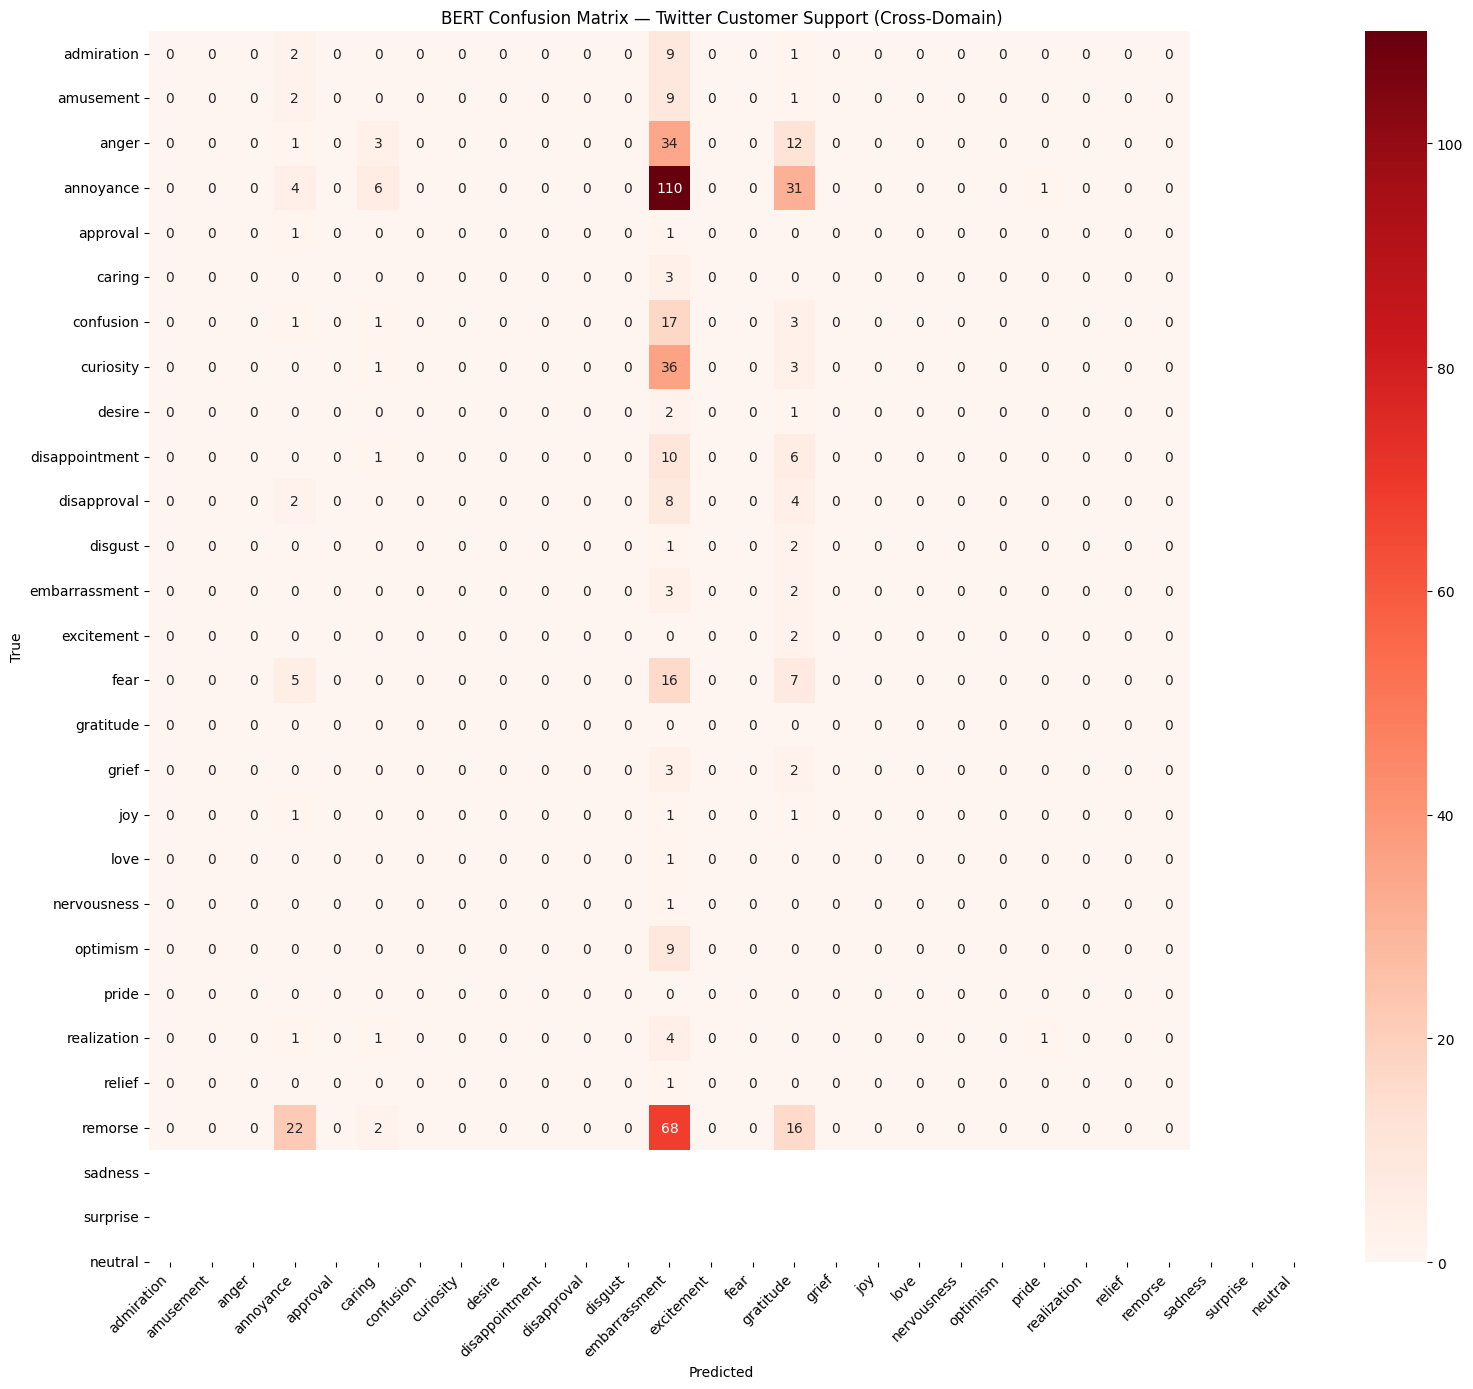

In [94]:
# ============================================================
# Confusion Matrix for Twitter (cross-domain)
# ============================================================

cm_twitter = confusion_matrix(twitter_true_labels, twitter_bert_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(
     cm_twitter, annot=True, fmt='d', cmap='Reds',
     xticklabels=emotion_labels, yticklabels=emotion_labels
 )
plt.title('BERT Confusion Matrix — Twitter Customer Support (Cross-Domain)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_twitter.png', dpi=150)
plt.show()


In [98]:
# ============================================================
# Most confused emotion pairs (Twitter)
# ============================================================

# # Find the top misclassified pairs
misclassified = []
n_labels = cm_twitter.shape[0]
for i in range(n_labels):
    for j in range(n_labels):
        if i != j and cm_twitter[i][j] > 0:
            misclassified.append({
                'true_emotion': emotion_labels[i] if i < len(emotion_labels) else str(i),
                'predicted_emotion': emotion_labels[j] if j < len(emotion_labels) else str(j),
                'count': cm_twitter[i][j]
            })

misclassified_df = pd.DataFrame(misclassified).sort_values('count', ascending=False)
print("Top 15 most confused emotion pairs (Twitter):")
print(misclassified_df.head(15).to_string(index=False))


Top 15 most confused emotion pairs (Twitter):
  true_emotion predicted_emotion  count
     annoyance     embarrassment    110
       remorse     embarrassment     68
     curiosity     embarrassment     36
         anger     embarrassment     34
     annoyance         gratitude     31
       remorse         annoyance     22
     confusion     embarrassment     17
          fear     embarrassment     16
       remorse         gratitude     16
         anger         gratitude     12
disappointment     embarrassment     10
      optimism     embarrassment      9
    admiration     embarrassment      9
     amusement     embarrassment      9
   disapproval     embarrassment      8


In [100]:
# ============================================================
# Qualitative error examples
# ============================================================

# # Show specific misclassified examples for qualitative analysis
errors_df = annotated_df.copy()
errors_df['predicted_label'] = [emotion_labels[p] for p in twitter_bert_preds]
errors_df['correct'] = errors_df['final_label'] == errors_df['predicted_label']

# # Show misclassified examples
wrong = errors_df[~errors_df['correct']]
print(f"\nTotal misclassified: {len(wrong)} / {len(errors_df)} ({len(wrong)/len(errors_df):.1%})")
print("\n--- Sample Misclassified Tweets ---")
for _, row in wrong.head(20).iterrows():
     print(f"\nTweet: {row['text_clean'][:120]}")
     print(f"True: {row['final_label']} → Predicted: {row['predicted_label']}")


Total misclassified: 493 / 500 (98.6%)

--- Sample Misclassified Tweets ---

Tweet: @user Shame the g-f one is 50p more expensive than the regular one though :/
True: disappointment → Predicted: excitement

Tweet: @user I‚Äôm switching to @user
True: annoyance → Predicted: excitement

Tweet: @user is useless. Telling me they can't help me on the phone even though I'm the only person on my account. #stupid
True: anger → Predicted: excitement

Tweet: @user It's going to cost me ¬£42 to return this faulty item. Are you going to cover this?
True: annoyance → Predicted: excitement

Tweet: Ok.. I wish @user fix this darn phone.
True: annoyance → Predicted: excitement

Tweet: @user is my weakness
True: love → Predicted: annoyance

Tweet: @user When I pay ¬£417 for my monthly season ticket, I expect you 2 get me 2 London and back. Even when it‚Äôs due 2 a l
True: anger → Predicted: caring

Tweet: @user recibi llamadas de celulares 3113552287 y 3114248440 de supuestos representantes suyos, avi

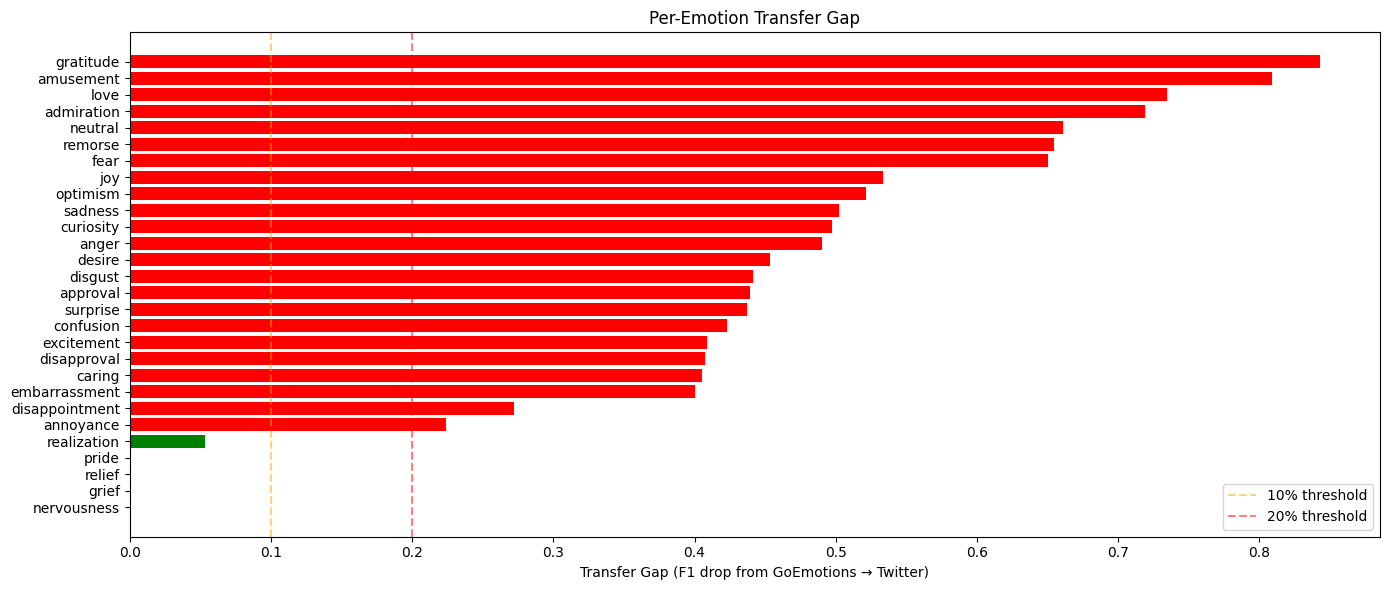

In [104]:
# ============================================================
# Per-emotion transfer gap (which emotions transfer best?)
# ============================================================
# Get per-label F1 for GoEmotions (in-domain)
bert_f1_goe = f1_score(bert_true, bert_preds, average=None, zero_division=0)

# Get per-label F1 for Twitter using same label set
from sklearn.metrics import classification_report
twitter_report = classification_report(twitter_true_labels, twitter_bert_preds, output_dict=True, zero_division=0)

# Build aligned arrays for all 28 emotions
bert_f1_twit_aligned = []
for i, label in enumerate(emotion_labels):
    if str(i) in twitter_report:
        bert_f1_twit_aligned.append(twitter_report[str(i)]['f1-score'])
    else:
        bert_f1_twit_aligned.append(0.0)

bert_f1_goe = np.array(bert_f1_goe)
bert_f1_twit_aligned = np.array(bert_f1_twit_aligned)

transfer_df = pd.DataFrame({
    'Emotion': emotion_labels,
    'F1_GoEmotions': bert_f1_goe,
    'F1_Twitter': bert_f1_twit_aligned,
    'Gap': bert_f1_goe - bert_f1_twit_aligned
}).sort_values('Gap', ascending=False)


# # Plot
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(emotion_labels))
sorted_df = transfer_df.sort_values('Gap', ascending=True)
colors = ['green' if g <= 0.1 else 'orange' if g <= 0.2 else 'red' for g in sorted_df['Gap']] 
ax.barh(sorted_df['Emotion'], sorted_df['Gap'], color=colors)
ax.set_xlabel('Transfer Gap (F1 drop from GoEmotions → Twitter)')
ax.set_title('Per-Emotion Transfer Gap')
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='10% threshold')
ax.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='20% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('per_emotion_transfer_gap.png', dpi=150)
plt.show()

### 7.1 Grouped Emotion Evaluation (Fallback)

If 27-class performance is too low, group into broader categories and re-evaluate.

In [107]:
# Emotion grouping (broader categories)
emotion_groups = {
    'negative': ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust',
                 'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness'],
    'positive': ['admiration', 'amusement', 'approval', 'caring', 'desire',
                 'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief'],
    'ambiguous': ['confusion', 'curiosity', 'realization', 'surprise', 'neutral']
}

# Create mapping from fine-grained to grouped
label_to_group = {}
for group, emotions in emotion_groups.items():
    for emotion in emotions:
        label_to_group[emotion] = group

print("Emotion grouping:")
for group, emotions in emotion_groups.items():
    print(f"  {group}: {emotions}")

# ============================================================
# Uncomment after cross-domain evaluation
# ============================================================

# # Map predictions and true labels to groups
twitter_true_grouped = [label_to_group[emotion_labels[l]] for l in twitter_true_labels]
twitter_pred_grouped = [label_to_group[emotion_labels[p]] for p in twitter_bert_preds]

grouped_acc = accuracy_score(twitter_true_grouped, twitter_pred_grouped)
grouped_f1 = f1_score(twitter_true_grouped, twitter_pred_grouped, average='weighted', zero_division=0)

print(f"\n--- Grouped Emotion Results (Twitter) ---")
print(f"Accuracy:    {grouped_acc:.4f}")
print(f"Weighted F1: {grouped_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(twitter_true_grouped, twitter_pred_grouped, zero_division=0))

Emotion grouping:
  negative: ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness']
  positive: ['admiration', 'amusement', 'approval', 'caring', 'desire', 'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief']
  ambiguous: ['confusion', 'curiosity', 'realization', 'surprise', 'neutral']

--- Grouped Emotion Results (Twitter) ---
Accuracy:    0.2480
Weighted F1: 0.2142

Classification Report:
              precision    recall  f1-score   support

   ambiguous       0.00      0.00      0.00       171
    negative       0.49      0.27      0.35       246
    positive       0.16      0.69      0.26        83

    accuracy                           0.25       500
   macro avg       0.21      0.32      0.20       500
weighted avg       0.27      0.25      0.21       500



---
## 8. Results Summary

Compile all key results here for the report.

In [109]:
# ============================================================
# Final summary table — uncomment after all experiments are done
# ============================================================

results_summary = pd.DataFrame({
     'Model': ['Logistic Regression', 'Logistic Regression', 'BERT', 'BERT'],
     'Domain': ['GoEmotions (in-domain)', 'Twitter (cross-domain)',
                'GoEmotions (in-domain)', 'Twitter (cross-domain)'],
     'Accuracy': [lr_accuracy, twitter_lr_acc,
                  bert_eval['eval_accuracy'], twitter_bert_acc],
     'Macro F1': [lr_f1_macro, twitter_lr_f1_macro,
                  bert_eval['eval_f1_macro'], twitter_bert_f1_macro],
     'Weighted F1': [lr_f1_weighted, twitter_lr_f1_weighted,
                     bert_eval['eval_f1_weighted'], twitter_bert_f1_weighted]
 })

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(results_summary.to_string(index=False))
print("="*70)


FINAL RESULTS SUMMARY
              Model                 Domain  Accuracy  Macro F1  Weighted F1
Logistic Regression GoEmotions (in-domain)  0.503225  0.305047     0.446242
Logistic Regression Twitter (cross-domain)  0.278000  0.150627     0.185773
               BERT GoEmotions (in-domain)  0.583932  0.429969     0.566174
               BERT Twitter (cross-domain)  0.014000  0.002331     0.012707


---
## 9. Emotion Distribution in Customer Support

What emotions are most prevalent in customer support interactions?

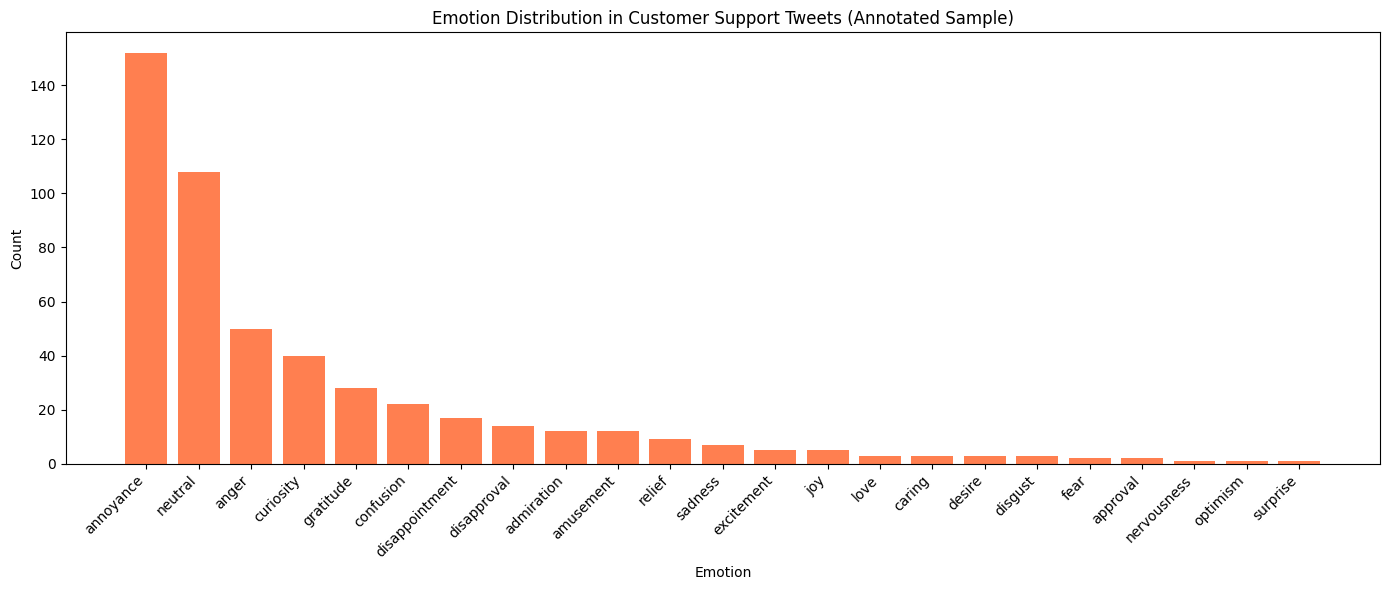

In [111]:
# ============================================================
# Uncomment after annotation is complete
# ============================================================

# # Distribution of emotions in annotated Twitter sample
twitter_emotion_counts = Counter(annotated_df['final_label'])
sorted_twitter = sorted(twitter_emotion_counts.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(14, 6))
labels_tw, counts_tw = zip(*sorted_twitter)
plt.bar(labels_tw, counts_tw, color='coral')
plt.xticks(rotation=45, ha='right')
plt.title('Emotion Distribution in Customer Support Tweets (Annotated Sample)')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('twitter_emotion_distribution.png', dpi=150)
plt.show()

---
## 10. Business Recommendations

Based on our findings, we provide actionable recommendations for deploying emotion AI in customer service contexts.

*This section will be filled in after results are available — Marcus to write.*